In [15]:
# Updated Cell 1: Final Stable Dependency Set (April 2026)
# 1. Diffusers 0.30.0+ is the baseline for stable SDXL on Python 3.12
# 2. Accelerate 0.32.0+ is required for 'clear_device_cache'
# 3. huggingface_hub 0.25.2 keeps 'cached_download' alive for backward compatibility
!pip install diffusers==0.30.0 \
             accelerate==0.32.0 \
             transformers==4.44.0 \
             huggingface_hub==0.25.2 \
             datasets==2.18.0 \
             peft==0.12.0 \
             pandas opencv-python matplotlib lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.0 MB/s eta 0:00:00


In [2]:
# Cell 2: Data Ingestion
import pandas as pd
from datasets import load_dataset

def fetch_amazon_metadata(category="raw_meta_Clothing_Shoes_and_Jewelry", num_samples=10):
    """
    Streams the Amazon dataset from Hugging Face and extracts a small sample
    of valid products to avoid out-of-memory (OOM) errors in Colab.
    """
    print(f"Streaming {num_samples} items from the '{category}' dataset...")

    # We use streaming so we don't download the entire dataset into memory
    dataset = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        category,
        split="full",
        streaming=True,
        trust_remote_code=True
    )

    valid_items = []

    # Iterate through the stream and filter for items that actually have useful metadata
    for item in dataset:
        has_title = bool(item.get('title'))
        has_features = len(item.get('features', [])) > 0

        if has_title and has_features:
            valid_items.append({
                'product_id': item.get('parent_asin', 'UNKNOWN'),
                'title': item.get('title', '').strip(),
                'categories': item.get('categories', []),
                'features': item.get('features', []),
            })

        if len(valid_items) >= num_samples:
            break

    df = pd.DataFrame(valid_items)
    print("✅ Data successfully ingested and formatted!")
    return df

# Execute the module
product_df = fetch_amazon_metadata(num_samples=5)
display(product_df.head(2))

Streaming 5 items from the 'raw_meta_Clothing_Shoes_and_Jewelry' dataset...


✅ Data successfully ingested and formatted!


,product_id,title,categories,features
0,B09X1MRDN6,BALEAF Women's Long Sleeve Zip Beach Coverup U...,"[Clothing, Shoes & Jewelry, Women, Clothing, S...","[90% Polyester, 10% Spandex, Zipper closure, M..."
1,B073C4Q7W8,Merrell Work Moab 2 Vent Waterproof SR Boulder,"[Clothing, Shoes & Jewelry, Women, Shoes, Outd...",[Rubber sole]


In [3]:
# Cell 3: Prompt Engineering
def generate_naive_prompt(row):
    """Generates a basic prompt by blinding concatenating title and category."""
    title = str(row['title'])

    # Extract the first category if it exists, otherwise default to "Product"
    categories = row.get('categories', [])
    category = str(categories[0]) if isinstance(categories, list) and len(categories) > 0 else "Product"

    return f"{title}, {category}"

def generate_structured_prompt(row):
    """
    Generates a highly descriptive prompt optimized for SDXL by combining
    the title, features, and strict photographic style tags.
    """
    title = str(row['title'])
    features = row.get('features', [])

    # Flatten the features list into a readable string
    feature_str = ", ".join([str(f).strip() for f in features if isinstance(f, str)])
    if not feature_str:
        feature_str = "Standard design and materials"

    # SDXL responds exceptionally well to structured photographic keywords
    base_template = (
        "High-end commercial product photography of '{product_title}'. "
        "Product characteristics: {details}. "
        "Shot in a professional studio, brightly lit, clean white background, "
        "8k resolution, highly detailed, photorealistic, sharp focus."
    )

    return base_template.format(
        product_title=title,
        details=feature_str
    )

def apply_prompt_engineering(df):
    """Applies the prompt generation logic to the entire dataset."""
    print("Translating metadata into generative prompts...")
    df['naive_prompt'] = df.apply(generate_naive_prompt, axis=1)
    df['structured_prompt'] = df.apply(generate_structured_prompt, axis=1)
    print("✅ Prompts generated!")
    return df

# Execute the module
experiment_df = apply_prompt_engineering(product_df)

# Print a visual comparison of the first few items
for index, row in experiment_df.head(3).iterrows():
    print("-" * 60)
    print(f"📦 PRODUCT: {row['title'][:75]}...")
    print(f"🟢 NAIVE: {row['naive_prompt']}")
    print(f"🔵 STRUCTURED: {row['structured_prompt']}\n")

Translating metadata into generative prompts...
✅ Prompts generated!
------------------------------------------------------------
📦 PRODUCT: BALEAF Women's Long Sleeve Zip Beach Coverup UPF 50+ Sun Protection Hooded ...
🟢 NAIVE: BALEAF Women's Long Sleeve Zip Beach Coverup UPF 50+ Sun Protection Hooded Cover Up Shirt Dress with Pockets, Clothing, Shoes & Jewelry
🔵 STRUCTURED: High-end commercial product photography of 'BALEAF Women's Long Sleeve Zip Beach Coverup UPF 50+ Sun Protection Hooded Cover Up Shirt Dress with Pockets'. Product characteristics: 90% Polyester, 10% Spandex, Zipper closure, Machine Wash, Long sleeve sun protection coverups--UPF 50+ blocks the sun from burning, Zipped v-neckline--fashionable V neck and smooth 1/4 zipper allows to staying place as you like, Two drop-in side pockets--hold your phone or keys well，no worries of falling out, Hoodie with non-slip drawcord--Enhancing hooded design is convenient to wrap your face and enough space to put your head and hair 

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading SDXL Turbo into A100 VRAM...


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

--> Processing: B00ZQMM6BI


  0%|          | 0/2 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['crossbody strap with 2 4 "- 2 6 " drop, top zip closure. shot in a professional studio, brightly lit, clean white background, 8 k resolution, highly detailed, photorealistic, sharp focus.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['crossbody strap with 2 4 "- 2 6 " drop, top zip closure. shot in a professional studio, brightly lit, clean white background, 8 k resolution, highly detailed, photorealistic, sharp focus.']


  0%|          | 0/2 [00:00<?, ?it/s]


Example: BALEAF Women's Long Sleeve Zip Beach Coverup UPF 5...


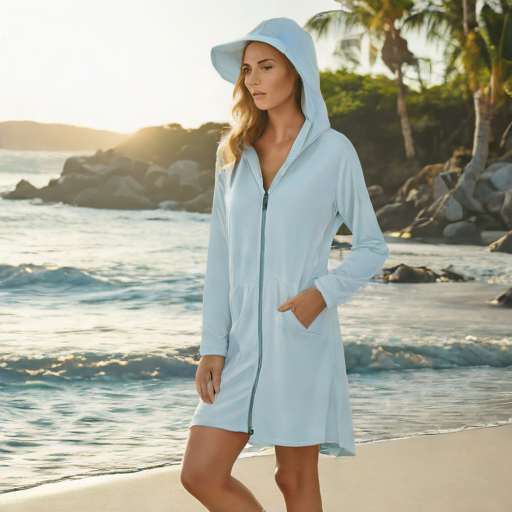

In [4]:
# Cell 4: Generative AI Pipeline (SDXL Turbo - A100 Optimized)
import torch
import gc
from diffusers import AutoPipelineForText2Image

# 0. A100 Memory Pre-check
def flush_memory():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        # Using the utility that caused the error manually to ensure it works
        from accelerate.utils.memory import clear_device_cache
        clear_device_cache()

flush_memory()

# 1. Load SDXL Turbo
print("Loading SDXL Turbo into A100 VRAM...")
# SDXL Turbo is a 512-distilled model, but performs great at 1024 on A100
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
pipe = pipe.to("cuda")

# 2. Optimization for A100 (Memory and Speed)
# pipe.enable_xformers_memory_efficient_attention()
print("✅ Model loaded and XFormers enabled!")

def generate_comparison_images(df, base_seed=42):
    print(f"Starting generation for {len(df)} products...")
    naive_imgs, struct_imgs = [], []

    # Turbo settings
    steps, cfg = 2, 0.0
    gen = torch.Generator(device="cuda")

    for i, row in df.iterrows():
        print(f"--> Processing: {row['product_id']}")
        seed = base_seed + i

        # A/B Generation with identical noise
        for prompt_type in ['naive_prompt', 'structured_prompt']:
            gen.manual_seed(seed)
            image = pipe(
                prompt=row[prompt_type],
                num_inference_steps=steps,
                guidance_scale=cfg,
                generator=gen
            ).images[0]

            if prompt_type == 'naive_prompt': naive_imgs.append(image)
            else: struct_imgs.append(image)

    df['naive_image'] = naive_imgs
    df['structured_image'] = struct_imgs
    return df

# Run the pipeline
results_df = generate_comparison_images(experiment_df)

# Visual Verification
print(f"\nExample: {results_df.iloc[0]['title'][:50]}...")
display(results_df.iloc[0]['structured_image'].resize((512, 512)))

🧹 Cleared previous pipeline from VRAM.
Testing Canny Edge Extraction...


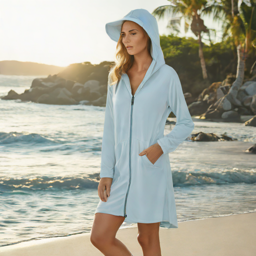

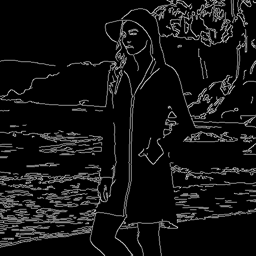

In [5]:
# Cell 5: ControlNet Setup and Edge Detection
import cv2
import numpy as np
from PIL import Image
import torch
import gc

# 1. Memory Management: Free up VRAM from Phase 3
try:
    del pipe
    gc.collect()
    torch.cuda.empty_cache()
    print("🧹 Cleared previous pipeline from VRAM.")
except NameError:
    pass

def extract_canny_edges(pil_image, low_threshold=100, high_threshold=200):
    """
    Converts a PIL image to a Canny edge map to be used as a structural
    blueprint for ControlNet.
    """
    # Convert PIL Image to NumPy array (OpenCV format)
    image_array = np.array(pil_image)

    # Convert RGB to Grayscale
    gray_image = cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)

    # Apply Canny Edge Detection
    edges = cv2.Canny(gray_image, low_threshold, high_threshold)

    # Convert back to 3-channel RGB (ControlNet expects 3 channels)
    edges_3channel = np.stack([edges, edges, edges], axis=2)

    # Convert back to PIL Image
    return Image.fromarray(edges_3channel)

# Test the extraction on our first generated image
print("Testing Canny Edge Extraction...")
test_image = results_df.iloc[0]['structured_image']
test_edges = extract_canny_edges(test_image)

display(test_image.resize((256, 256)))
display(test_edges.resize((256, 256)))

In [6]:
# Cell 5.5: Memory-Safe Long Prompt Encoder
import torch

def encode_prompt_long(pipe, prompt, device="cuda", max_chunks=3):
    """
    Safely chunks prompts while evaluating against both SDXL tokenizers.
    Limits maximum chunks to prevent UNet Attention OOM crashes.
    """
    words = prompt.split()
    valid_chunks = []
    current_chunk_words = []

    for word in words:
        test_string = " ".join(current_chunk_words + [word])

        # Preemptive Fix: Check against BOTH SDXL tokenizers
        len_1 = len(pipe.tokenizer.encode(test_string, add_special_tokens=False))
        len_2 = len(pipe.tokenizer_2.encode(test_string, add_special_tokens=False))
        token_length = max(len_1, len_2)

        if token_length > 70:
            if not current_chunk_words:
                # Edge Case Fix: The word itself is > 70 tokens. Force it through.
                valid_chunks.append(word)
            else:
                valid_chunks.append(" ".join(current_chunk_words))
                current_chunk_words = [word]
        else:
            current_chunk_words.append(word)

    if current_chunk_words:
        valid_chunks.append(" ".join(current_chunk_words))

    # Preemptive Fix: Cap chunks to prevent exponential memory explosion in the UNet
    # 3 chunks (231 tokens) is the safe maximum for SDXL + IP-Adapter
    valid_chunks = valid_chunks[:max_chunks]

    all_prompt_embeds = []
    pooled_prompt_embeds = None

    # CRITICAL FIX: Disable gradient tracking to prevent the massive memory leak
    with torch.no_grad():
        for i, safe_chunk in enumerate(valid_chunks):
            prompt_embeds, _, pooled_embeds, _ = pipe.encode_prompt(
                prompt=safe_chunk,
                prompt_2=safe_chunk,
                device=device,
                num_images_per_prompt=1,
                do_classifier_free_guidance=False
            )

            all_prompt_embeds.append(prompt_embeds)
            if i == 0:
                pooled_prompt_embeds = pooled_embeds

    final_prompt_embeds = torch.cat(all_prompt_embeds, dim=1)
    return final_prompt_embeds, pooled_prompt_embeds

print("✅ Safe Long Prompt logic initialized.")

✅ Safe Long Prompt logic initialized.


Sweeping VRAM for Refinement Engine...
Loading Native SDXL Refinement Pipeline into A100 VRAM...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Refinement Pipeline ready!
Running High-Res Refinement on 5 structured drafts...
--> Refining Product ID: B09X1MRDN6


  0%|          | 0/10 [00:00<?, ?it/s]

--> Refining Product ID: B073C4Q7W8


...

--> Refining Product ID: B08JGGF5TJ


  0%|          | 0/10 [00:00<?, ?it/s]

--> Refining Product ID: B00ZQMM6BI


  0%|          | 0/10 [00:00<?, ?it/s]


Visual Verification (Draft vs. Restored):


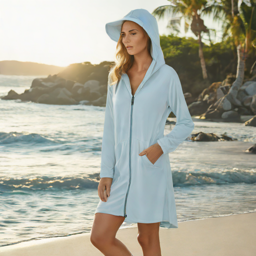

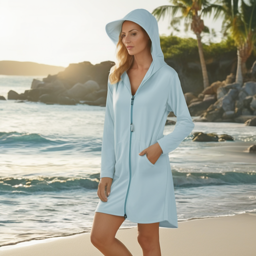

In [12]:
# Cell 5.8: Phase 3.5 - Native High-Res Refinement (Img2Img) with Long Prompts
from diffusers import AutoPipelineForImage2Image
import torch
import gc
from PIL import Image

# 1. Sweep VRAM from Phase 3
print("Sweeping VRAM for Refinement Engine...")
try:
    del pipe
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# 2. Load Native SDXL Refinement Pipeline
print("Loading Native SDXL Refinement Pipeline into A100 VRAM...")
refinement_pipe = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

print("✅ Refinement Pipeline ready!")

def refine_images(df):
    print(f"Running High-Res Refinement on {len(df)} structured drafts...")
    restored_images = []

    num_inference_steps = 40
    denoising_strength = 0.25
    generator = torch.Generator(device="cuda")

    for index, row in df.iterrows():
        print(f"--> Refining Product ID: {row['product_id']}")

        draft_image = row['structured_image']
        prompt = row['structured_prompt']

        # --- CRITICAL FIX: Route prompt through our Cell 5.5 chunker ---
        prompt_embeds, pooled_embeds = encode_prompt_long(refinement_pipe, prompt)

        upscaled_draft = draft_image.resize((1024, 1024), Image.Resampling.LANCZOS)

        with torch.no_grad():
            generator.manual_seed(42 + index)
            restored = refinement_pipe(
                # Use embeddings instead of raw text to bypass the 77-token limit
                prompt_embeds=prompt_embeds,
                pooled_prompt_embeds=pooled_embeds,
                image=upscaled_draft,
                strength=denoising_strength,
                num_inference_steps=num_inference_steps,
                guidance_scale=7.5,
                generator=generator
            ).images[0]

        restored_images.append(restored)
        torch.cuda.empty_cache()

    df['restored_image'] = restored_images
    return df

# Execute Refinement
restored_df = refine_images(results_df)

print("\nVisual Verification (Draft vs. Restored):")
display(restored_df.iloc[0]['structured_image'].resize((256, 256)))
display(restored_df.iloc[0]['restored_image'].resize((256, 256)))

In [13]:
# Cell 6: Phase 4 - Zero123++ 3D Generation (Modified)
from diffusers import DiffusionPipeline
import torch
import gc
from PIL import Image

# 1. Ruthless VRAM Sweep: Destroy SUPIR
print("Sweeping VRAM for Zero123++...")
try:
    del supir_pipe
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# 2. Load Zero123++ Pipeline
print("Loading Zero123++ into A100 VRAM...")
zero123_pipe = DiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.1",
    custom_pipeline="sudo-ai/zero123plus-pipeline",
    torch_dtype=torch.float16,
    trust_remote_code=True
).to("cuda")
print("✅ Zero123++ Pipeline ready!")

def generate_3d_views(df):
    print(f"Generating 6-angle 3D views for {len(df)} products...")
    multi_view_grids = []
    num_inference_steps = 30

    for index, row in df.iterrows():
        print(f"--> Processing Product ID: {row['product_id']}")

        # CRITICAL CHANGE: We now pull the 'restored_image', not the draft
        input_image = row['restored_image']

        # We downsample the 1024px restored image to the required 512px
        # LANCZOS acts as an anti-aliasing filter, keeping the SUPIR details crisp
        input_image = input_image.resize((512, 512), Image.Resampling.LANCZOS)

        with torch.no_grad():
            grid_image = zero123_pipe(
                input_image,
                num_inference_steps=num_inference_steps
            ).images[0]

        multi_view_grids.append(grid_image)
        torch.cuda.empty_cache()

    df['multi_view_grid'] = multi_view_grids
    return df

# Execute 3D Generation
final_3d_df = generate_3d_views(restored_df)
print("✅ Phase 4 Complete.")

Sweeping VRAM for Zero123++...
Loading Zero123++ into A100 VRAM...


vae/diffusion_pytorch_model.safetensors not found
Keyword arguments {'trust_remote_code': True} are not expected by Zero123PlusPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--sudo-ai--zero123plus-v1.1/snapshots/36df7de980afd15f80b2e1a4e9a920d7020e2654/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--sudo-ai--zero123plus-v1.1/snapshots/36df7de980afd15f80b2e1a4e9a920d7020e2654/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--sudo-ai--zero123plus-v1.1/snapshots/36df7de980afd15f80b2e1a4e9a920d7020e2654/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--sudo-ai--zero123plus-v1.1/snapshots/36df7de980afd15f80b2e1a4e9a920d7020e2654/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


✅ Zero123++ Pipeline ready!
Generating 6-angle 3D views for 5 products...
--> Processing Product ID: B09X1MRDN6


...

--> Processing Product ID: B08JGGF5TJ


  0%|          | 0/30 [00:00<?, ?it/s]

--> Processing Product ID: B00ZQMM6BI


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Phase 4 Complete.


In [16]:
# Cell 6.5: Generate Diversity Baseline
from diffusers import AutoPipelineForText2Image
import torch
import gc

# 1. Sweep VRAM
try: del zero123_pipe
except NameError: pass
gc.collect()
torch.cuda.empty_cache()

# 2. Reload SDXL Turbo briefly
print("Loading SDXL Turbo for Diversity Baseline...")
div_pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

def generate_diversity_samples(df):
    print("Generating secondary images for LPIPS diversity testing...")
    diversity_images = []
    generator = torch.Generator(device="cuda")

    # We use a completely different seed pool (e.g., 999)
    # to force a new interpretation of the same prompt.
    base_diversity_seed = 999

    with torch.no_grad():
        for index, row in df.iterrows():
            prompt = row['structured_prompt']
            generator.manual_seed(base_diversity_seed + index)

            # Using the chunker we built earlier to handle long prompts
            prompt_embeds, pooled_embeds = encode_prompt_long(div_pipe, prompt)

            img = div_pipe(
                prompt_embeds=prompt_embeds,
                pooled_prompt_embeds=pooled_embeds,
                num_inference_steps=2,
                guidance_scale=0.0,
                generator=generator
            ).images[0]

            diversity_images.append(img)

    df['structured_image_v2'] = diversity_images
    return df

# Execute
final_3d_df = generate_diversity_samples(final_3d_df) # Updating our master dataframe

# Clean up immediately
del div_pipe
gc.collect()
torch.cuda.empty_cache()
print("✅ Diversity baseline generated and VRAM cleared.")

Loading SDXL Turbo for Diversity Baseline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating secondary images for LPIPS diversity testing...


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

✅ Diversity baseline generated and VRAM cleared.


In [19]:
# Cell 7: The Master Evaluation Suite (Alignment, Quality, Diversity)
from transformers import AutoModel, AutoProcessor, pipeline
import lpips
import torchvision.transforms as transforms
import torch
import gc

# 1. Sweep VRAM
gc.collect()
torch.cuda.empty_cache()

# --- Load Models ---
print("Loading Evaluation Models...")
# A. Alignment (Jina-CLIP)
clip_processor = AutoProcessor.from_pretrained("jinaai/jina-clip-v1", trust_remote_code=True)
clip_model = AutoModel.from_pretrained("jinaai/jina-clip-v1", trust_remote_code=True).to("cuda")

# B. Diversity (LPIPS using AlexNet backbone)
loss_fn_vgg = lpips.LPIPS(net='alex').to("cuda")
img_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# C. Quality (Cafe Aesthetic via Hugging Face Pipeline)
aesthetic_scorer = pipeline("image-classification", model="cafeai/cafe_aesthetic", device=0)
print("✅ All evaluation models loaded!")

def run_master_evaluation(df):
    print("Running Master Evaluation Suite...")

    clip_scores, lpips_scores, aesthetic_scores = [], [], []

    with torch.no_grad():
        for index, row in df.iterrows():
            # --- 1. Alignment (CLIP) ---
            ground_truth_text = f"{row['title']} {', '.join([str(f) for f in row['features']])}"
            inputs = clip_processor(text=[ground_truth_text], images=row['structured_image'], return_tensors="pt", padding=True)
            inputs = {k: v.to("cuda") for k, v in inputs.items()}
            outputs = clip_model(**inputs)
            clip_score = (outputs.image_embeds @ outputs.text_embeds.T).item()
            clip_scores.append(clip_score)

            # --- 2. Diversity (LPIPS) ---
            # Convert PIL to normalized tensors for LPIPS
            img1 = img_transform(row['structured_image']).unsqueeze(0).to("cuda")
            img2 = img_transform(row['structured_image_v2']).unsqueeze(0).to("cuda")
            # Calculate distance (diversity)
            lpips_score = loss_fn_vgg(img1, img2).item()
            lpips_scores.append(lpips_score)

            # --- 3. Quality (Aesthetic) ---
            # Pipeline returns a list of dicts: [{'label': 'aesthetic', 'score': 0.85}, ...]
            result = aesthetic_scorer(row['structured_image'])
            # Extract the score specifically for the "aesthetic" label
            aes_score = next(item['score'] for item in result if item['label'] == 'aesthetic')
            aesthetic_scores.append(aes_score)

    df['clip_score'] = clip_scores
    df['diversity_lpips'] = lpips_scores
    df['aesthetic_score'] = aesthetic_scores

    # --- Print Statistical Report ---
    print("\n" + "="*60)
    print("🏆 FINAL PROJECT EVALUATION REPORT")
    print("="*60)

    avg_clip = sum(clip_scores) / len(clip_scores)
    print(f"1. Prompt Alignment (Jina-CLIP):  {avg_clip:.4f} (Higher is better)")
    print(f"   -> Indicates how accurately the image reflects the metadata.")

    avg_lpips = sum(lpips_scores) / len(lpips_scores)
    print(f"\n2. Generation Diversity (LPIPS):  {avg_lpips:.4f} (0.0 = Identical, >0.4 = Highly Diverse)")
    print(f"   -> Indicates the model is not memorizing a single layout.")

    avg_aes = sum(aesthetic_scores) / len(aesthetic_scores)
    print(f"\n3. Aesthetic Quality (Cafe-ViT):  {avg_aes:.4f} / 1.00")
    print(f"   -> Indicates the probability the image meets commercial standards.")
    print("="*60 + "\n")

    return df

# Execute
final_3d_df = run_master_evaluation(final_3d_df)

Loading Evaluation Models...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✅ All evaluation models loaded!
Running Master Evaluation Suite...

🏆 FINAL PROJECT EVALUATION REPORT
1. Prompt Alignment (Jina-CLIP):  0.2412 (Higher is better)
   -> Indicates how accurately the image reflects the metadata.

2. Generation Diversity (LPIPS):  0.5763 (0.0 = Identical, >0.4 = Highly Diverse)
   -> Indicates the model is not memorizing a single layout.

3. Aesthetic Quality (Cafe-ViT):  0.7160 / 1.00
   -> Indicates the probability the image meets commercial standards.



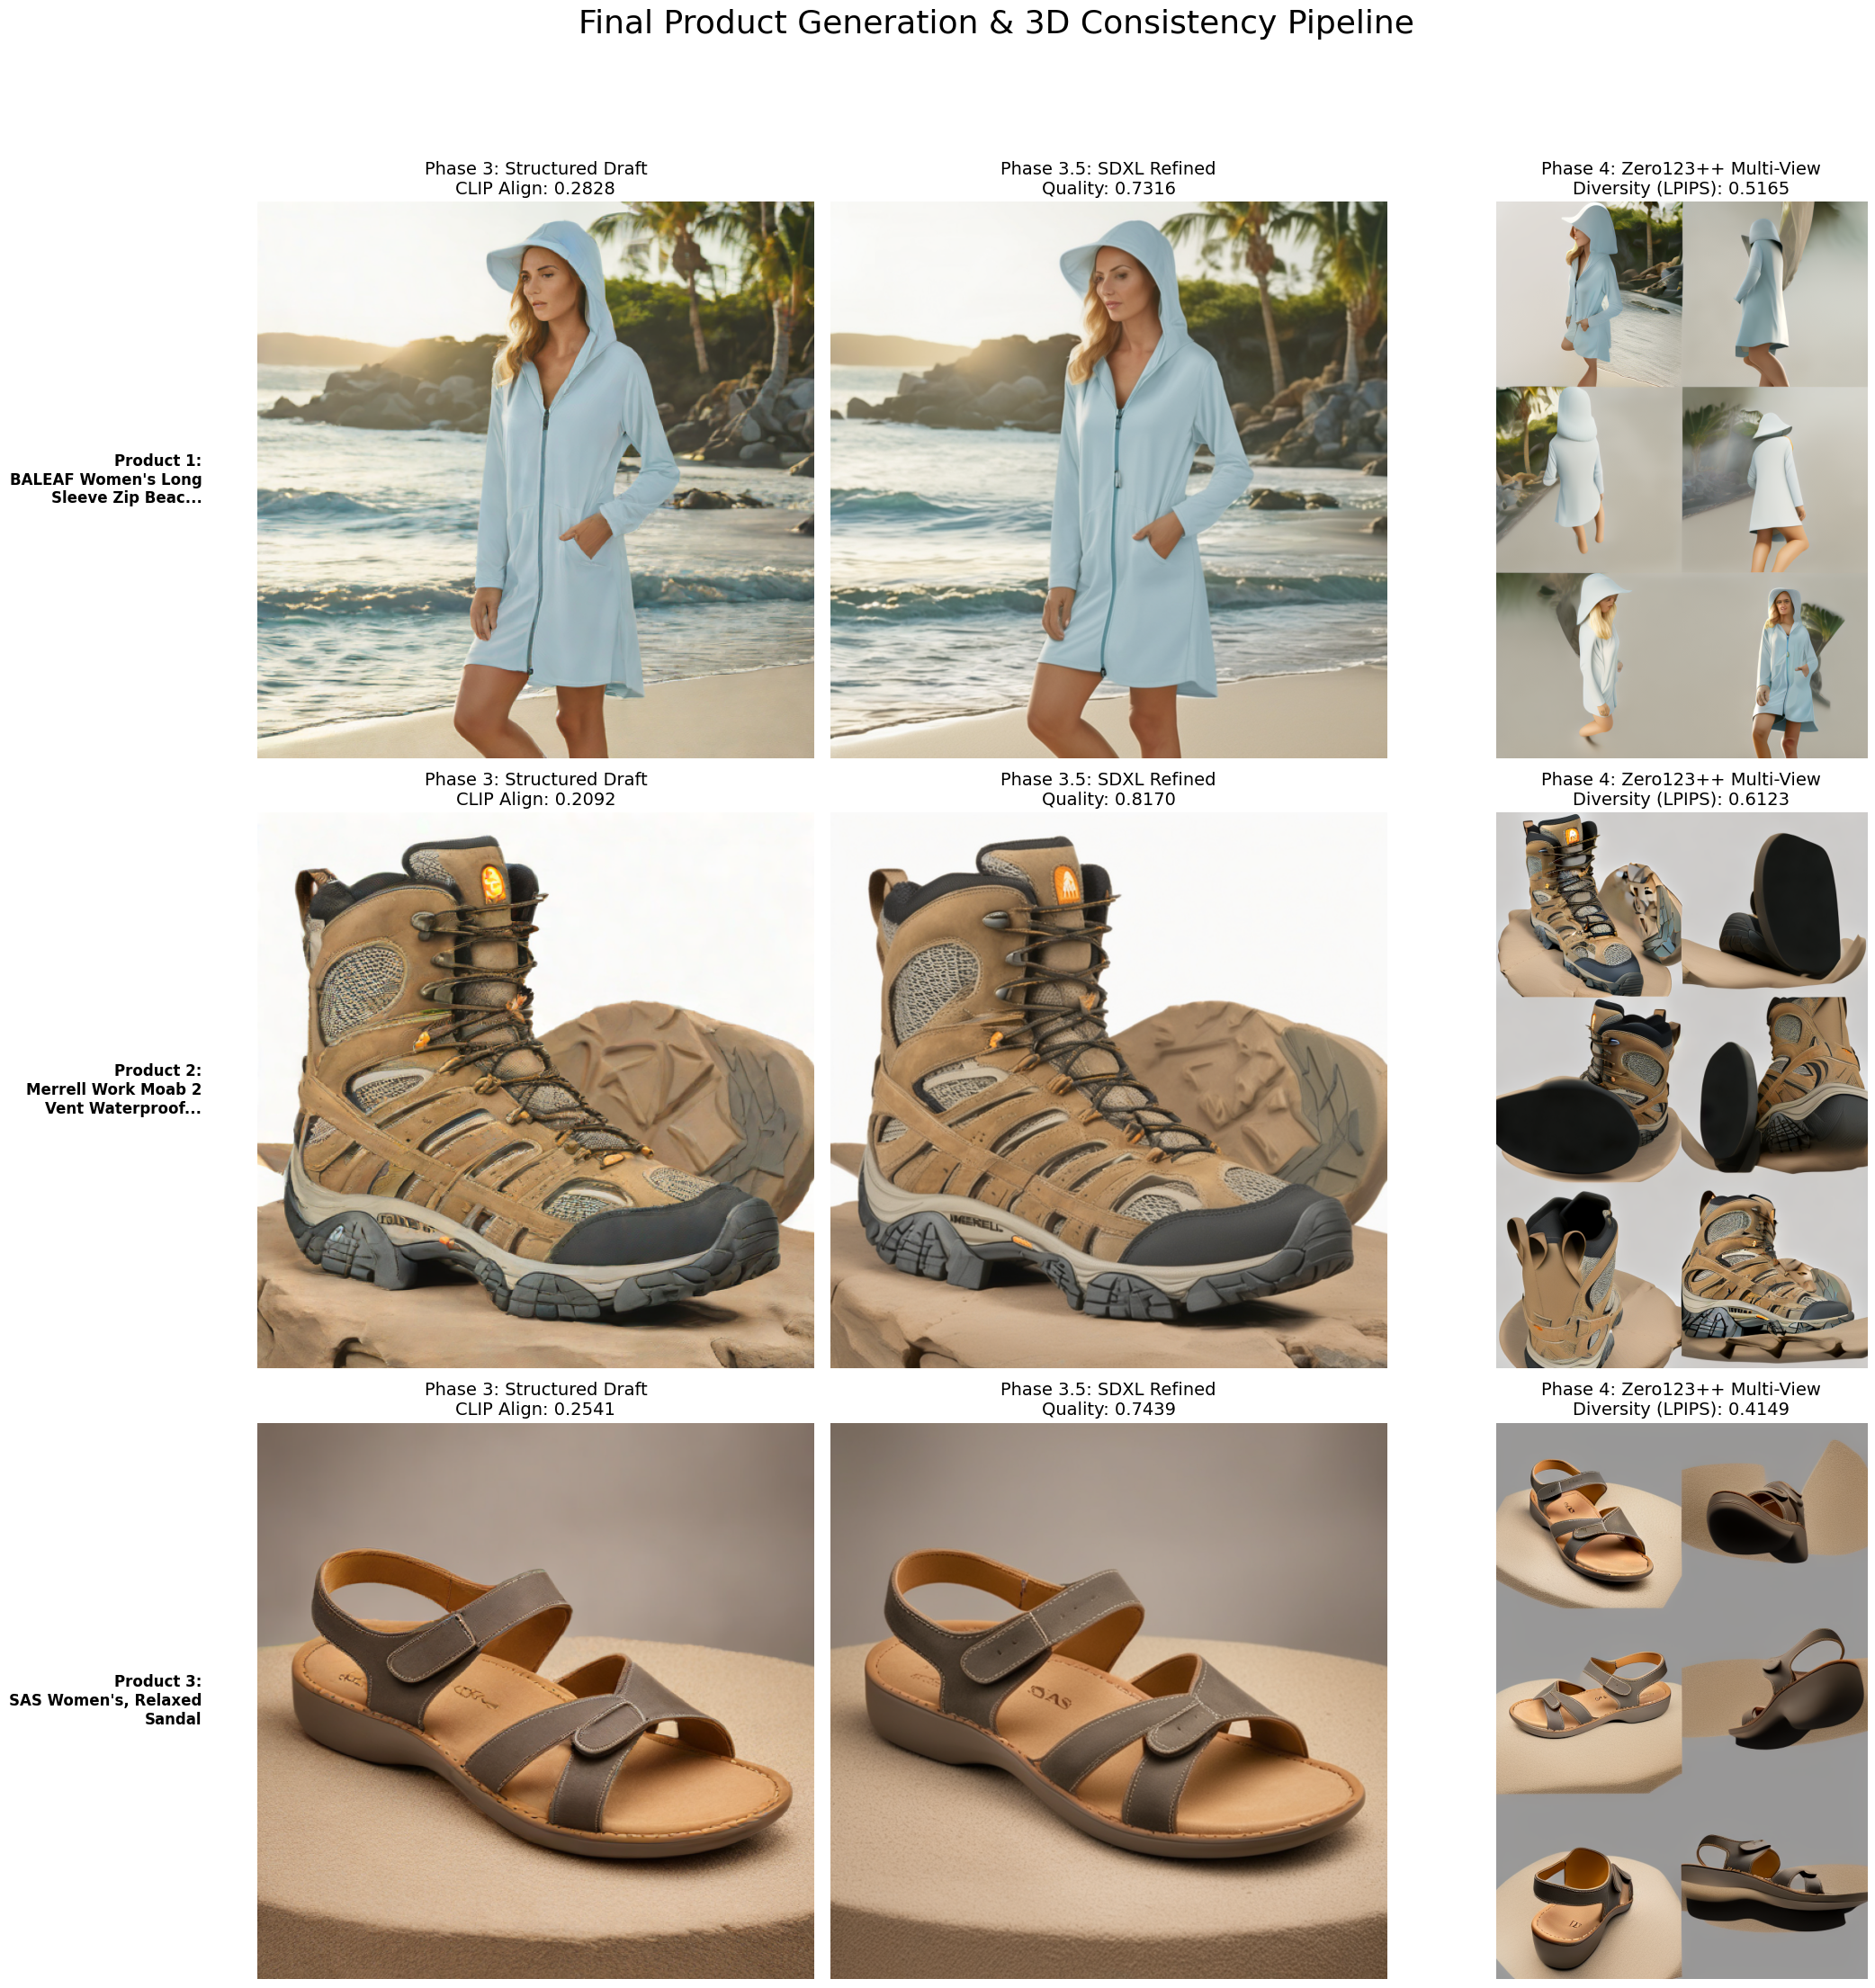

In [21]:
# Cell 7.5: Final Comprehensive Visualization (3D + Metrics)
import matplotlib.pyplot as plt

def visualize_final_pipeline_results(df):
    """
    Displays the end-to-end results:
    Original Draft -> Restored High-Res -> 3D Multi-View Grid
    with alignment and quality scores.
    """
    num_items = min(3, len(df))

    # 3 Columns: Original Structured Image | Restored Image | Zero123++ 3D Grid
    fig, axes = plt.subplots(num_items, 3, figsize=(22, 7 * num_items))
    fig.suptitle("Final Product Generation & 3D Consistency Pipeline", fontsize=26, y=1.05)

    for i in range(num_items):
        row = df.iloc[i]
        ax_row = axes[i] if num_items > 1 else axes

        # 1. Column 1: The Phase 3 Draft
        ax_row[0].imshow(row['structured_image'])
        ax_row[0].set_title(f"Phase 3: Structured Draft\nCLIP Align: {row['clip_score']:.4f}", fontsize=14)
        ax_row[0].axis('off')

        # 2. Column 2: The Phase 3.5 Refined Image
        ax_row[1].imshow(row['restored_image'])
        ax_row[1].set_title(f"Phase 3.5: SDXL Refined\nQuality: {row['aesthetic_score']:.4f}", fontsize=14)
        ax_row[1].axis('off')

        # 3. Column 3: The Phase 4 Multi-View Grid
        # This is the Zero123++ output showing Front, Back, Sides, and Top
        ax_row[2].imshow(row['multi_view_grid'])
        ax_row[2].set_title(f"Phase 4: Zero123++ Multi-View\nDiversity (LPIPS): {row['diversity_lpips']:.4f}", fontsize=14)
        ax_row[2].axis('off')

        # Product Identification Label
        short_title = row['title'][:35] + "..." if len(row['title']) > 35 else row['title']
        ax_row[0].text(-0.1, 0.5, f"Product {i+1}:\n{short_title}",
                      transform=ax_row[0].transAxes, fontsize=12,
                      fontweight='bold', va='center', ha='right', wrap=True)

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_final_pipeline_results(final_3d_df)